<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/LinearRegression-5.8-Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
data = pd.read_csv("BodyWeight_Dataset.csv")

In [ ]:
data.head()

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male


In [ ]:
data.shape

(30, 4)

In [ ]:
data.isnull().sum()

,0
Weight,0
Height,0
Age,0
Gender,0


In [ ]:
data["Gender"] = data["Gender"].map({
    "Male":1,
    "Female":0
})

data.head()

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1


In [ ]:
X = data.iloc[:,1:].values
y = data.iloc[:,0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Predicted Weight:")
print(y_pred)

print("\nActual Weight:")
print(y_test)

Predicted Weight:
[57.54397419 72.85156392 59.92676861 80.92502046 61.29873987 69.83455211]

Actual Weight:
[59 72 62 77 64 69]


In [ ]:
score = r2_score(y_test, y_pred)

print("R² Score =", score)

R² Score = 0.865352550574541


In [ ]:
print("Intercept =", model.intercept_)

print("\nCoefficients:")

features = ["Height", "Age", "Gender"]

for feature, coef in zip(features, model.coef_):
    print(feature, "=", coef)

Intercept = -19.60169296785766

Coefficients:
Height = 45.80598327228854
Age = 0.27527754826193496
Gender = 6.331504224395278


In [ ]:
new_person = [[1.75, 30, 1]]

prediction = model.predict(new_person)

print("Predicted Weight =", prediction[0])

Predicted Weight = 75.14860843090062


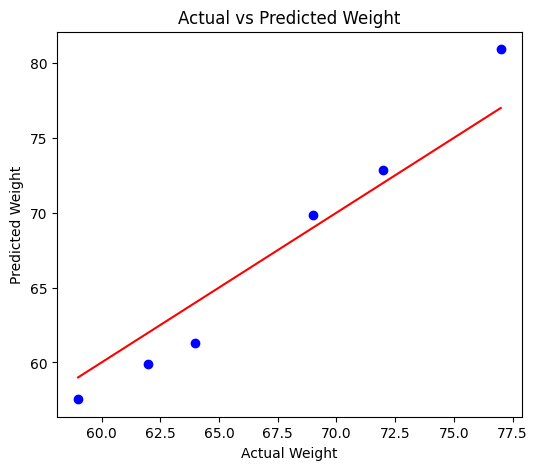

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, color="blue")

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red"
)

plt.title("Actual vs Predicted Weight")
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")

plt.show()